## module 3 — garden layout generation

compose: generate a planting plan for a bed — which plants, where, how many. published
generative garden design is pixel-space (pix2pix / FastGAN / SD img2img on ~100 scraped
plans — Senem et al. DLA 2024; Land 2025) with no plant identity. we go structured: a plan
is a set of (species, x, y, spread) tuples, the same object LayoutTransformer / LayoutDM
generate. no planting-plan dataset exists, so we sample one from horticultural rules
(rainer & west layers), and the rules double as metrics. arc: random baseline → rule
generator → layout transformer trained on rule plans (this notebook) → masked-diffusion
completion (11) → controlnet render (12). shared primitives live in `bvtrain/garden.py`.

runtime: ~5 min total on a small gpu (data ~1 min, training ~2 min), cpu ok too.

In [1]:
# get bvtrain (shared plumbing): locally it's ../bvtrain; on colab/kaggle clone the repo
import os, sys
_CANDS = ["..", ".", "botanical-vision"]
if not any(os.path.isdir(f"{p}/bvtrain") for p in _CANDS):
    os.system("git clone -q https://github.com/babnigg/botanical-vision")
sys.path[:0] = [p for p in _CANDS if os.path.isdir(f"{p}/bvtrain")]

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm, trange

from bvtrain import garden as g

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.facecolor"] = "linen"
DEV

'cuda'

### plant palette

16 ornamentals from the classifier's 4,094-species vocabulary, traits hand-seeded
(the curated trait table in `models/planned.json` replaces this later). layers per
rainer & west: structural anchors, seasonal theme plants, filler, groundcover. sun is
unused here — notebook 09 conditions on it.

In [2]:
pd.DataFrame(g.PALETTE)

,name,layer,h,s,sun,color
0,Hydrangea macrophylla,structural,150,150,1,cornflowerblue
1,Rosa rugosa,structural,150,120,2,palevioletred
2,Buxus sempervirens,structural,120,100,1,darkolivegreen
3,Monarda didyma,seasonal,110,45,1,firebrick
4,Echinacea purpurea,seasonal,100,45,2,mediumorchid
5,Hemerocallis fulva,seasonal,90,60,1,darkorange
6,Rudbeckia hirta,seasonal,90,40,2,gold
7,Achillea millefolium,seasonal,70,45,2,seashell
8,Leucanthemum vulgare,seasonal,60,40,2,white
9,Salvia nemorosa,seasonal,50,35,2,rebeccapurple


### rule generator

taller toward the back, odd-count single-species drifts, spacing from mature spread,
groundcover at the front edge. these plans are the training set; the same rules double
as the scoring metrics — every plan (random, rule-made, model-made) is graded on the
same constraints (1 = clean): no crowding, no tall-in-front, canopy coverage near 75%,
odd drifts.

{'overlap': 1.0,
 'height': 0.925,
 'cover': 0.591666616426078,
 'drift': 1.0,
 'score': 0.8791666541065195}

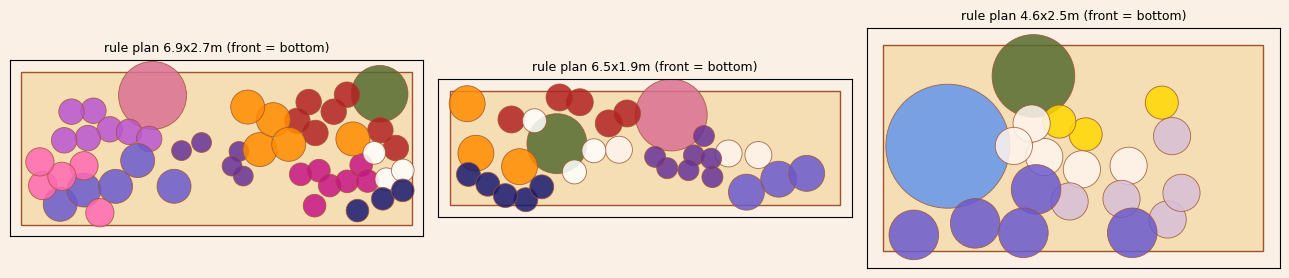

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax in axes:
    w, d = g.rand_bed()
    g.show_plan(g.gen_plan(w, d), w, d, ax, f"rule plan {w}x{d}m (front = bottom)")
plt.tight_layout()

g.score(g.gen_plan(5.0, 2.4), 5.0, 2.4)

### dummy baseline

uniform-random species and positions at a matched plant count — the floor everything
else has to beat.

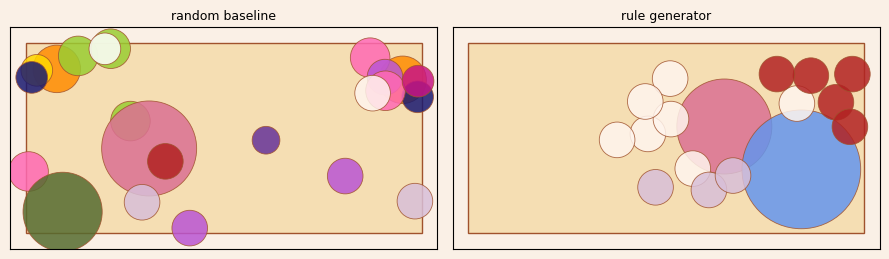

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
g.show_plan(g.gen_random(5.0, 2.4), 5.0, 2.4, axes[0], "random baseline")
g.show_plan(g.gen_plan(5.0, 2.4), 5.0, 2.4, axes[1], "rule generator")
plt.tight_layout()

In [5]:
def eval_gen(fn, n=150, desc="eval"):
    rows = []
    for _ in trange(n, desc=desc, leave=False):
        w, d = g.rand_bed()
        rows.append(g.score(fn(w, d), w, d))
    return pd.DataFrame(rows).mean().round(3)

results = pd.DataFrame({"random": eval_gen(g.gen_random, desc="random"),
                        "rules": eval_gen(g.gen_plan, desc="rules")})
results

random:   0%|          | 0/150 [00:00<?, ?it/s]

rules:   0%|          | 0/150 [00:00<?, ?it/s]

,random,rules
overlap,0.948,1.000
height,0.711,0.988
cover,0.632,0.678
drift,0.218,0.995
score,0.627,0.915


### layout transformer

plans become token sequences — bed-size prefix, then (species, x, y) triples on a 32x12
grid, back-to-front — so a small gpt-style decoder (~1M params) can learn the rules from
sampled plans. same family as LayoutTransformer / LayoutDM, scaled to train in minutes
on any gpu (or cpu).

In [6]:
NX, NY, NW, ND = 32, 12, 9, 7          # x/y grid, bed width/depth buckets
PAD, BOS, EOS = 0, 1, 2
T_W  = 3
T_D  = T_W + NW
T_SP = T_D + ND
T_X  = T_SP + len(g.PALETTE)
T_Y  = T_X + NX
VOCAB = T_Y + NY
MAXP = 60; MAXLEN = 3 + 3 * MAXP + 1

def bed_tokens(w, d):
    return [BOS, T_W + min(NW - 1, int((w - 3.5) / 0.5)), T_D + min(ND - 1, int((d - 1.8) / 0.2))]

def encode(plan, w, d):
    t = bed_tokens(w, d)
    for i, x, y, r in sorted(plan, key=lambda p: (-p[2], p[1]))[:MAXP]:   # back-to-front
        t += [T_SP + i, T_X + min(NX - 1, int(x / w * NX)), T_Y + min(NY - 1, int(y / d * NY))]
    t.append(EOS)
    return t + [PAD] * (MAXLEN - len(t))

def decode(tokens, w, d):
    plan = []
    ts = [t for t in tokens if t >= T_SP]
    for k in range(0, len(ts) - 2, 3):
        s, x, y = ts[k], ts[k + 1], ts[k + 2]
        if not (T_SP <= s < T_X and T_X <= x < T_Y and T_Y <= y < VOCAB): break
        i = s - T_SP
        plan.append((i, (x - T_X + 0.5) / NX * w, (y - T_Y + 0.5) / NY * d, g.PALETTE[i]["s"] / 200))
    return plan

N_PLANS = 4000
X = torch.tensor([encode(g.gen_plan(*bd), *bd)
                  for bd in (g.rand_bed() for _ in trange(N_PLANS, desc="rule plans"))])
X.shape

rule plans:   0%|          | 0/4000 [00:00<?, ?it/s]

torch.Size([4000, 184])

In [7]:
class LayoutLM(nn.Module):
    def __init__(self, v=VOCAB, dm=128, heads=4, layers=4, ctx=MAXLEN):
        super().__init__()
        self.tok = nn.Embedding(v, dm); self.pos = nn.Embedding(ctx, dm)
        blk = nn.TransformerEncoderLayer(dm, heads, dm * 4, dropout=0.1,
                                         batch_first=True, norm_first=True)
        self.tf = nn.TransformerEncoder(blk, layers, enable_nested_tensor=False)
        self.head = nn.Linear(dm, v)
    def forward(self, x):
        n = x.shape[1]
        h = self.tok(x) + self.pos(torch.arange(n, device=x.device))
        mask = nn.Transformer.generate_square_subsequent_mask(n, device=x.device)
        return self.head(self.tf(h, mask=mask, is_causal=True))

model = LayoutLM().to(DEV)
sum(p.numel() for p in model.parameters())

836943

In [8]:
EPOCHS = 12
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X), batch_size=64, shuffle=True)
model.train()
for ep in range(EPOCHS):
    tot = n = 0
    bar = tqdm(loader, desc=f"epoch {ep + 1}/{EPOCHS}", leave=False)
    for (xb,) in bar:
        xb = xb.to(DEV)
        loss = F.cross_entropy(model(xb[:, :-1]).reshape(-1, VOCAB), xb[:, 1:].reshape(-1),
                               ignore_index=PAD)
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item(); n += 1
        bar.set_postfix(loss=f"{tot / n:.3f}")
    print(f"epoch {ep + 1:2d}  loss {tot / n:.3f}")

epoch 1/12:   0%|          | 0/63 [00:00<?, ?it/s]

C:\Users\daniel\anaconda3\lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


epoch  1  loss 3.140


epoch 2/12:   0%|          | 0/63 [00:00<?, ?it/s]

epoch  2  loss 2.170


...

epoch 10  loss 1.938


epoch 11/12:   0%|          | 0/63 [00:00<?, ?it/s]

epoch 11  loss 1.930


epoch 12/12:   0%|          | 0/63 [00:00<?, ?it/s]

epoch 12  loss 1.922


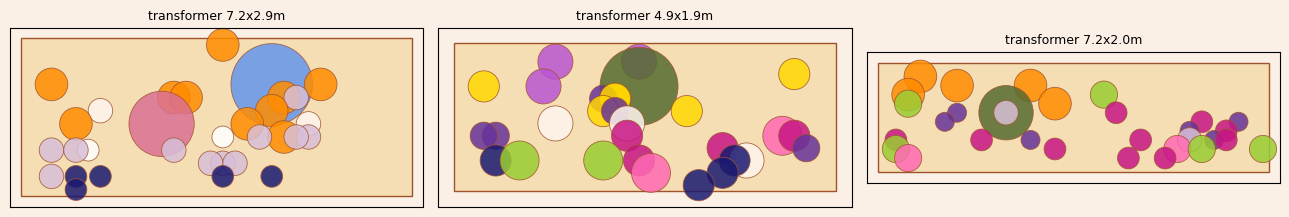

In [9]:
# grammar-constrained sampling: each slot draws only from its own token family
def sample_plan(w, d, temp=0.9):
    model.eval()
    t = bed_tokens(w, d)
    slots = [(T_SP, T_X), (T_X, T_Y), (T_Y, VOCAB)]
    with torch.no_grad():
        for k in range(MAXP * 3):
            logits = model(torch.tensor([t], device=DEV))[0, -1] / temp
            lo, hi = slots[k % 3]
            mask = torch.full_like(logits, float("-inf"))
            mask[lo:hi] = 0
            if k % 3 == 0: mask[EOS] = 0        # may stop before starting a triple
            tok = torch.multinomial(F.softmax(logits + mask, -1), 1).item()
            if tok == EOS: break
            t.append(tok)
    return decode(t, w, d)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax in axes:
    w, d = g.rand_bed()
    g.show_plan(sample_plan(w, d), w, d, ax, f"transformer {w}x{d}m")
plt.tight_layout()

transformer:   0%|          | 0/100 [00:00<?, ?it/s]

,random,rules,transformer
overlap,0.948,1.000,0.955
height,0.711,0.988,0.988
cover,0.632,0.678,0.654
drift,0.218,0.995,0.433
score,0.627,0.915,0.758


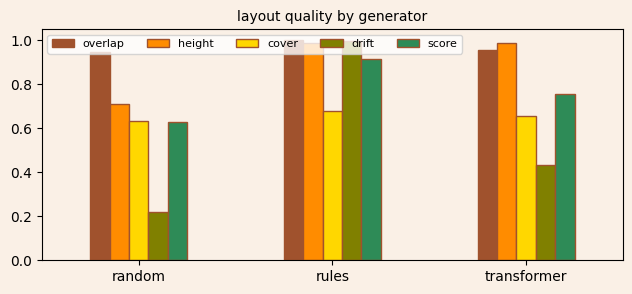

In [10]:
results["transformer"] = eval_gen(sample_plan, n=100, desc="transformer")
ax = results.T[["overlap", "height", "cover", "drift", "score"]].plot.bar(
    color=["sienna", "darkorange", "gold", "olive", "seagreen"],
    figsize=(7.5, 3), rot=0, edgecolor="sienna")
ax.set_facecolor("linen"); ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, ncols=5); ax.set_title("layout quality by generator", fontsize=10)
results

### takeaways

- one scale for everything: random 0.63 < transformer 0.77 < rules 0.91. the model learns
  height banding (0.99), spacing, and coverage from tokens alone — without ever seeing the
  scoring code — but misses odd-count drifts (0.45), a global discrete constraint that
  next-token sampling can't count its way through.
- an autoregressive model can also only condition on a *prefix*, so it can't do the real
  compose interaction — pin your toolbox plants anywhere, infill the rest. notebook
  `11_complete_layout` fixes both with masked discrete diffusion; `12_render_plan` turns
  plans into images via seg-controlnet.